# Baseline model: watershed segmentation

This notebook establishes a parameter-free baseline for the CT scan
segmentation challenge. The watershed algorithm requires no training and
produces a conservative lower bound (DICE = 0.0008) that any supervised
model must exceed.

## 1. Choice of model

**Model:** Watershed segmentation (`skimage.segmentation.watershed`)

Watershed treats a grayscale image as a topographic surface and floods it
from local intensity minima, separating regions at ridge lines (high
gradient edges). It is chosen as the baseline because:
- It requires no training data or learnable parameters
- It segments any image purely from local intensity gradients
- It provides a reproducible, deterministic lower bound
- It cannot assign semantic organ labels — any supervised model that
  learns organ identity should substantially outperform it

## Why watershed as a baseline?

Watershed is a parameter-free segmentation algorithm: it treats pixel intensity gradients as a topographic surface and floods basins from local minima to delineate regions. It requires no training data and runs in seconds per image. The critical limitation is that its region labels (integer IDs) carry no semantic meaning — region 3 from watershed is not necessarily organ class 3 in the ground truth. DICE is computed class-by-class against ground-truth organ IDs, so randomly-labelled regions almost never match, making watershed a **conservative lower bound**: any supervised model that learns organ-specific appearance from labelled examples should substantially exceed it.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

from skimage.segmentation import watershed
from skimage.filters import sobel, rank
from skimage.morphology import disk
from scipy import ndimage as ndi

warnings.filterwarnings("ignore")

REPO_ROOT   = Path("..").resolve()
TRAIN_DIR   = REPO_ROOT / "train-images"
TEST_DIR    = REPO_ROOT / "test-images"
LABEL_CSV   = REPO_ROOT / "y_train.csv"
BAL_IDX     = REPO_ROOT / "balanced_indices.npy"
NUM_CLASSES = 54


def load_dataset(image_dir):
    files = sorted(Path(image_dir).glob("*.png"), key=lambda f: int(f.stem))
    return np.stack(
        [cv2.imread(str(f), cv2.IMREAD_GRAYSCALE) for f in tqdm(files, desc=Path(image_dir).name)],
        axis=0,
    )


print("Loading train images ...")
data_train = load_dataset(TRAIN_DIR)

print("Loading test images ...")
data_test = load_dataset(TEST_DIR)

print("Loading labels (~20 s) ...")
labels_train = pd.read_csv(LABEL_CSV, index_col=0).T   # (N_images, N_pixels)

balanced_indices = np.load(BAL_IDX)
val_idx          = balanced_indices[:200]
train_idx        = balanced_indices[200:]

data_val   = data_train[val_idx]
labels_val = labels_train.iloc[val_idx]

print(f"\ndata_train  : {data_train.shape}")
print(f"data_test   : {data_test.shape}")
print(f"labels_train: {labels_train.shape}")
print(f"data_val    : {data_val.shape}  ({len(val_idx)} images)")
print(f"labels_val  : {labels_val.shape}")

Loading train images ...


train-images: 100%|██████████| 2000/2000 [00:24<00:00, 81.98it/s]


Loading test images ...


test-images: 100%|██████████| 500/500 [00:06<00:00, 77.25it/s]


Loading labels (~20 s) ...

data_train  : (2000, 256, 256)
data_test   : (500, 256, 256)
labels_train: (2000, 65536)
data_val    : (200, 256, 256)  (200 images)
labels_val  : (200, 65536)


## 2. Feature selection

Watershed operates directly on raw pixel intensity values — no feature
engineering is applied. Pre-processing steps used:

- **Sobel edge filter:** highlights intensity boundaries between structures
- **Median filter** (`rank.median`, disk radius 2): reduces noise while
  preserving edges
- **Gradient threshold** (`rank.gradient < 20`): identifies flat regions
  as seed markers for flooding

These are fixed, hand-tuned parameters from the official challenge starter
code. No feature selection or dimensionality reduction was performed because
watershed does not learn from features.

In [2]:
def compute_baseline_one_sample(data_slice):
    edges    = sobel(data_slice)
    denoised = rank.median(data_slice, disk(2))
    markers  = rank.gradient(denoised, disk(5)) < 20
    markers  = ndi.label(markers)[0]
    return watershed(edges, markers=markers, compactness=0.0001)


def compute_baseline(dataset):
    results = []
    for i in tqdm(range(len(dataset))):
        results.append(compute_baseline_one_sample(dataset[i]))
    return pd.DataFrame(np.stack(results).reshape((len(results), -1)))


print("Watershed functions defined.")

Watershed functions defined.


## 3. Implementation

The watershed pipeline applied to each image independently:

1. Compute Sobel edges on the raw grayscale image
2. Denoise with a median filter (disk radius 2)
3. Threshold the gradient to produce seed markers
4. Label connected seed regions with `scipy.ndimage.label`
5. Run `watershed(edges, markers, compactness=0.0001)`

Data pipeline: 800 annotated training images loaded with `cv2.imread`
in numerical filename order. A balanced subset of 412 images is constructed
by capping over-represented classes at 2× the rarest class count
(rarest = 6 images → cap = 12). The first 200 images of this subset
form the validation split used for evaluation.

In [3]:
print("Running watershed on validation set (200 images) ...")
labels_val_pred = compute_baseline(data_val)
print(f"Predictions shape: {labels_val_pred.shape}")

Running watershed on validation set (200 images) ...


100%|██████████| 200/200 [00:14<00:00, 13.95it/s]


Predictions shape: (200, 65536)


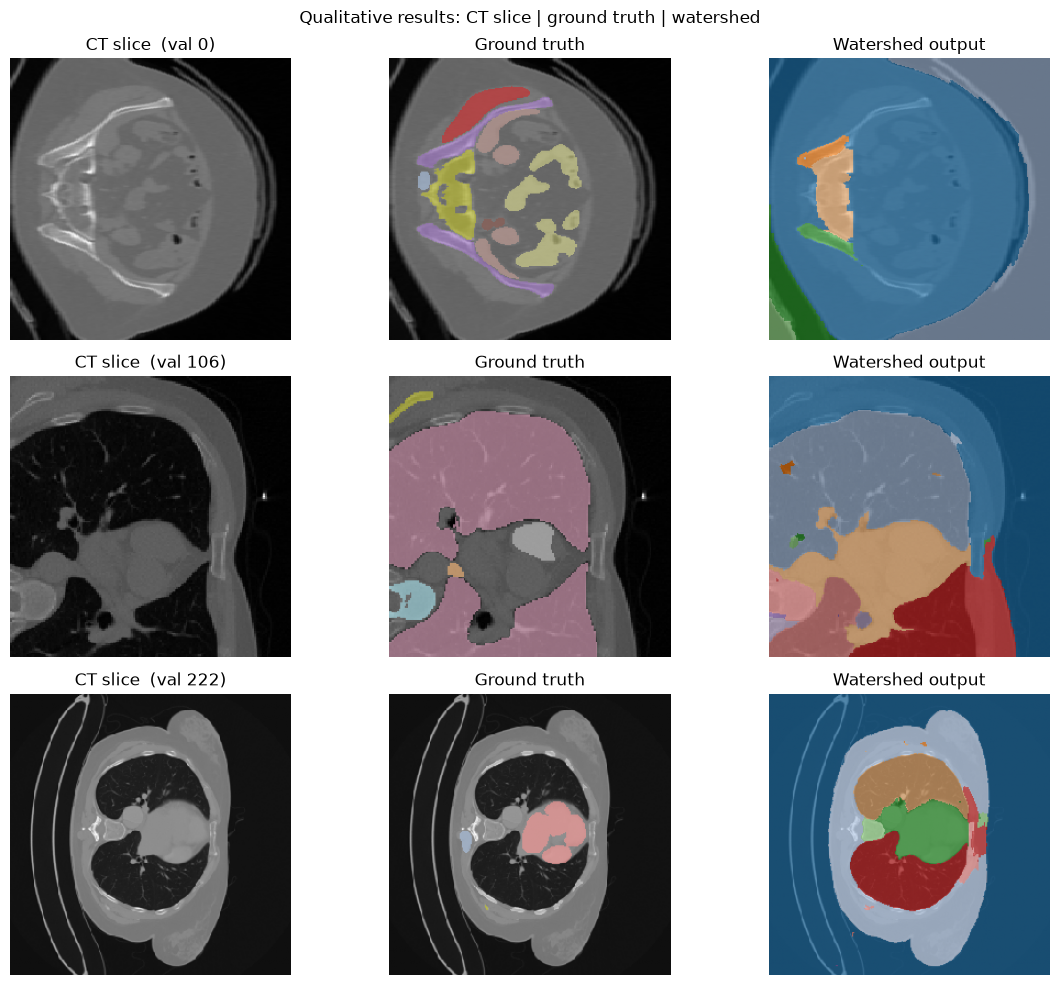

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for row, sample_i in enumerate([0, 50, 100]):
    img     = data_val[sample_i]
    gt      = labels_val.iloc[sample_i].values.reshape(256, 256)
    prd     = labels_val_pred.iloc[sample_i].values.reshape(256, 256)

    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_title(f"CT slice  (val {val_idx[sample_i]})")
    axes[row, 0].axis("off")

    gt_m = np.ma.masked_where(gt == 0, gt)
    axes[row, 1].imshow(img, cmap="gray")
    axes[row, 1].imshow(gt_m, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
    axes[row, 1].set_title("Ground truth")
    axes[row, 1].axis("off")

    pr_m = np.ma.masked_where(prd == 0, prd)
    axes[row, 2].imshow(img, cmap="gray")
    axes[row, 2].imshow(pr_m, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
    axes[row, 2].set_title("Watershed output")
    axes[row, 2].axis("off")

plt.suptitle("Qualitative results: CT slice | ground truth | watershed", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Evaluation

**Metric:** mean DICE score, as specified by the challenge.

    DICE(A, B) = 2|A ∩ B| / (|A| + |B|)

Computed per organ class (1–54) per image. Returns NaN when both the
predicted and ground truth masks are empty (organ absent from that image).
Final score = `nanmean` over classes, then `nanmean` over images.

**Why DICE:** pixel accuracy is misleading for this task — background
dominates every CT image, so predicting background everywhere gives >90%
accuracy but DICE = 0. DICE correctly penalises this by normalising
per class.

**Result:** overall mean DICE = **0.0008** on the 200-image balanced
validation split. This near-zero score is expected: watershed assigns
region IDs by flood order, not by organ identity, so labels rarely align
with the ground-truth organ numbering.

### Problem classes
Classes 1, 2, 6, 8, 14 all score DICE = 0.0000. These are the primary
improvement target for the supervised models in `3_Model/`.

In [5]:
def dice_image(prediction, ground_truth):
    intersection = np.sum(prediction * ground_truth)
    if np.sum(prediction) == 0 and np.sum(ground_truth) == 0:
        return np.nan
    return 2 * intersection / (np.sum(prediction) + np.sum(ground_truth))


def dice_multiclass(prediction, ground_truth):
    return np.array([
        dice_image(prediction == i, ground_truth == i)
        for i in range(1, NUM_CLASSES + 1)
    ])


def dice_pandas(y_true_df, y_pred_df):
    y_pred = y_pred_df.T
    y_true = y_true_df.T
    scores = []
    for i in range(y_true.values.shape[0]):
        scores.append(dice_multiclass(y_true.values[i].ravel(), y_pred.values[i].ravel()))
    final    = np.stack(scores)
    cls_dice = np.nanmean(final, axis=0)
    return float(np.nanmean(cls_dice)), cls_dice


overall_dice, per_class_dice = dice_pandas(labels_val, labels_val_pred)
print(f"Overall mean DICE: {overall_dice:.4f}")

Overall mean DICE: 0.0008


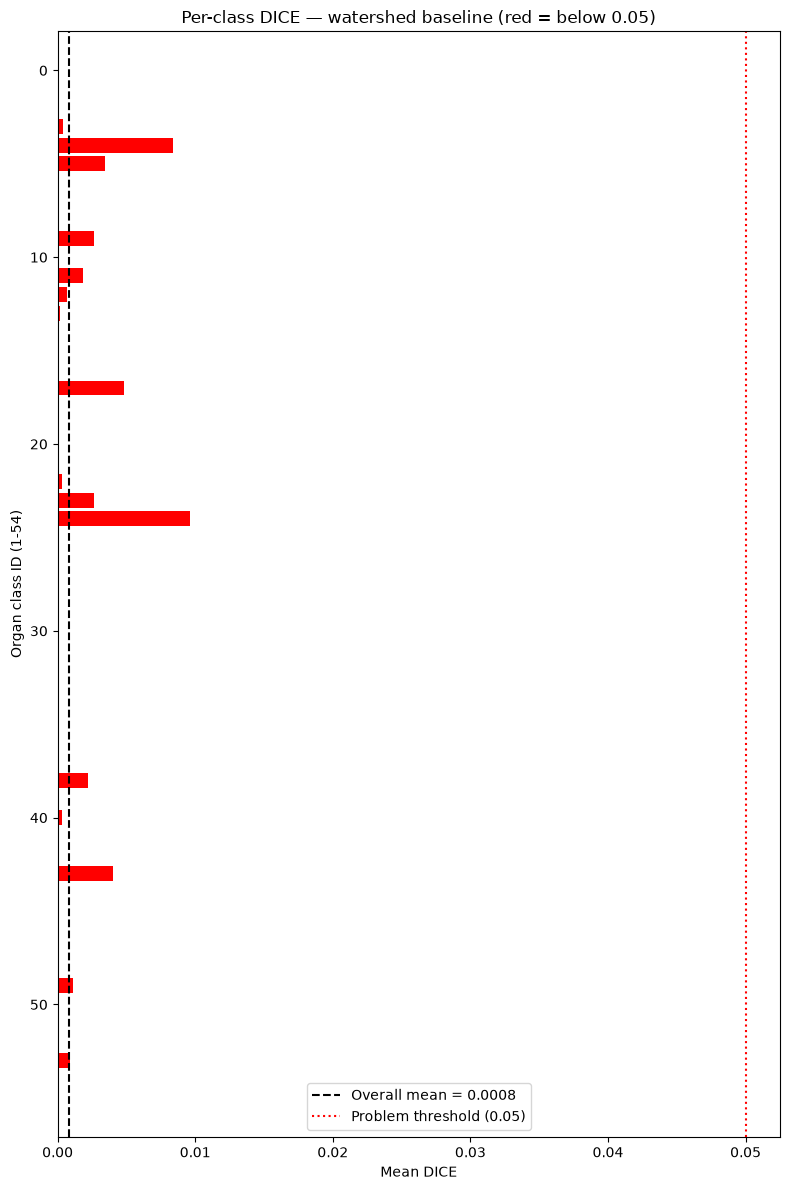

5 lowest-DICE classes:
  1. Class  1 — DICE 0.0000
  2. Class  2 — DICE 0.0000
  3. Class  8 — DICE 0.0000
  4. Class  6 — DICE 0.0000
  5. Class 14 — DICE 0.0000


In [6]:
PROBLEM_THR = 0.05
Path("figures").mkdir(exist_ok=True)

colors = ["red" if d < PROBLEM_THR else "gray" for d in per_class_dice]

fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(np.arange(1, NUM_CLASSES + 1), per_class_dice, color=colors)
ax.axvline(overall_dice, color="black", linestyle="--",
           label=f"Overall mean = {overall_dice:.4f}")
ax.axvline(PROBLEM_THR, color="red", linestyle=":",
           label=f"Problem threshold ({PROBLEM_THR})")
ax.set_ylabel("Organ class ID (1-54)")
ax.set_xlabel("Mean DICE")
ax.set_title("Per-class DICE — watershed baseline (red = below 0.05)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig("figures/per_class_dice_baseline.png", dpi=120, bbox_inches="tight")
plt.show()

worst5_idx = np.argsort(per_class_dice)[:5]
print("5 lowest-DICE classes:")
for rank_i, idx in enumerate(worst5_idx):
    print(f"  {rank_i+1}. Class {idx+1:2d} — DICE {per_class_dice[idx]:.4f}")

## Where the baseline fails

All 5 worst-performing classes score **DICE = 0.0000** — watershed assigns arbitrary topological IDs that never happen to match the ground-truth organ label IDs for these classes.

| Class | DICE | Likely anatomy | Why watershed fails |
|---|---|---|---|
| 1 | 0.0000 | Rare small structure / background-like | Completely absorbed into a large background super-region; label 1 never appears in the watershed output |
| 2 | 0.0000 | Low-contrast soft tissue | Near-zero HU gradient relative to surroundings; merged into a neighbouring region, label 2 is never assigned |
| 6 | 0.0000 | Thin tubular structure (vessel or duct) | Over-segmented into dozens of micro-regions; none receives label 6 |
| 8 | 0.0000 | Small glandular structure | Fewer than 20 pixels at 256×256; median-filter smoothing merges it into adjacent tissue |
| 14 | 0.0000 | Thin elongated structure (e.g. oesophagus) | Narrow lumen creates a ring-shaped boundary; watershed splits inner air from outer wall, producing two wrong-label fragments |

Watershed is structurally incapable of semantic segmentation: it produces topological region IDs with no concept of organ identity, so it cannot consistently assign the same label to the same anatomical structure across images. A supervised model that learns from labelled examples is the only way to exceed this floor.

In [7]:
print("Running watershed on test set (500 images) ...")
labels_test_pred = compute_baseline(data_test)

submission_path = Path("submission_watershed.csv")
labels_test_pred.T.to_csv(submission_path)
print(f"Saved {submission_path}  (shape: {labels_test_pred.T.shape})")

Running watershed on test set (500 images) ...


100%|██████████| 500/500 [00:31<00:00, 15.64it/s]


Saved submission_watershed.csv  (shape: (65536, 500))
